In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
from datasets import load_dataset
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt

# DUPLICATED MODEL ARCHITECTURE

In [2]:
class CNN_Advanced(nn.Module):
    def __init__(self, num_classes=16):
        super(CNN_Advanced, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 14 * 14, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))

# SETUP

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Testing on device: {device}")

Testing on device: cuda


In [7]:
print("Fetching model weights from Hugging Face...")
weights_path = hf_hub_download(
    repo_id="jagan78/plant-disease-architectures",
    filename="weights-16-class/cnn_advanced/cnn_advanced_best.pth", 
    repo_type="model"
)

Fetching model weights from Hugging Face...


weights-16-class/cnn_advanced/cnn_advanc(…):   0%|          | 0.00/51.8M [00:00<?, ?B/s]

In [8]:
model = CNN_Advanced(num_classes=16)
model.load_state_dict(torch.load(weights_path, map_location=device))
model = model.to(device)
model.eval()

/tmp/ipykernel_41792/300118170.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location=device))


CNN_Advanced(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [9]:
ds = load_dataset("jagan78/plant-disease-16-class", split="train", streaming=True)
class_names = ds.features['label'].names 

Resolving data files:   0%|          | 0/2460 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/323 [00:00<?, ?it/s]

# RUN INFERENCE ON A SINGLE IMAGE

In [15]:
sample = next(iter(ds))
raw_image = sample["image"]
true_label_idx = sample["label"]

In [16]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Add a batch dimension: [Channels, Height, Width] -> [1, Channels, Height, Width]
input_tensor = transform(raw_image.convert("RGB")).unsqueeze(0).to(device)

In [17]:
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    confidence, predicted_idx = torch.max(probabilities, 1)

# VISUALIZE THE RESULT

In [18]:
true_name = class_names[true_label_idx]
pred_name = class_names[predicted_idx.item()]
conf_score = confidence.item() * 100

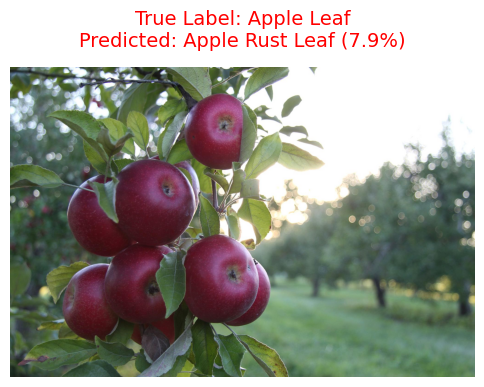

In [19]:
plt.figure(figsize=(6, 6))
plt.imshow(raw_image)
title_color = "green" if true_label_idx == predicted_idx.item() else "red"
plt.title(f"True Label: {true_name}\nPredicted: {pred_name} ({conf_score:.1f}%)", color=title_color, fontsize=14, pad=15)
plt.axis('off')
plt.show()